In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time

# 1. Detect available devices
device_gpu = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device_cpu = torch.device("cpu")
print(f"GPU device: {device_gpu}")
print(f"CPU device: {device_cpu}")

# 2. Load and split the data
data = fetch_california_housing()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42
)

# 3. Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# 4. Create PyTorch datasets & loaders
train_ds = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
)
test_ds = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)
)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=128)

# 5. Define a simple MLP
class MiniMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

# 6. Function to train and evaluate model on a specific device
def train_and_evaluate(device_name, device):
    print(f"\n--- Running on {device_name} ---")
    
    # Initialize model on the device
    model = MiniMLP(input_dim=X_train.shape[1]).to(device)
    
    # Set up training
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    num_epochs = 5
    
    # Training loop
    train_start_time = time.time()
    for epoch in range(num_epochs):
        model.train()
        epoch_start_time = time.time()
        total_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
        avg_loss = total_loss / len(train_loader.dataset)
        epoch_time = time.time() - epoch_start_time
        print(f"Epoch {epoch+1}/{num_epochs} — Train MSE: {avg_loss:.4f} — Time: {epoch_time:.2f}s")
    
    train_time = time.time() - train_start_time
    print(f"Total training time: {train_time:.2f}s")
    
    # Evaluation
    eval_start_time = time.time()
    model.eval()
    with torch.no_grad():
        total_loss = 0.0
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            total_loss += criterion(preds, yb).item() * xb.size(0)
        test_mse = total_loss / len(test_loader.dataset)
    eval_time = time.time() - eval_start_time
    print(f"Test MSE: {test_mse:.4f} — Evaluation time: {eval_time:.2f}s")
    
    return train_time, eval_time, test_mse

# 7. Run on GPU (if available)
if torch.cuda.is_available():
    gpu_train_time, gpu_eval_time, gpu_mse = train_and_evaluate("GPU", device_gpu)

# 8. Run on CPU
cpu_train_time, cpu_eval_time, cpu_mse = train_and_evaluate("CPU", device_cpu)

# 9. Compare results
if torch.cuda.is_available():
    print("\n--- Performance Comparison ---")
    print(f"GPU Training Time: {gpu_train_time:.2f}s | CPU Training Time: {cpu_train_time:.2f}s | Speedup: {cpu_train_time/gpu_train_time:.2f}x")
    print(f"GPU Evaluation Time: {gpu_eval_time:.2f}s | CPU Evaluation Time: {cpu_eval_time:.2f}s | Speedup: {cpu_eval_time/gpu_eval_time:.2f}x")
    print(f"GPU Test MSE: {gpu_mse:.4f} | CPU Test MSE: {cpu_mse:.4f}")


GPU device: cuda
CPU device: cpu

--- Running on GPU ---
Epoch 1/5 — Train MSE: 2.5185 — Time: 0.97s
Epoch 2/5 — Train MSE: 0.8660 — Time: 0.35s
Epoch 3/5 — Train MSE: 0.6782 — Time: 0.36s
Epoch 4/5 — Train MSE: 0.5574 — Time: 0.37s
Epoch 5/5 — Train MSE: 0.4925 — Time: 0.34s
Total training time: 2.40s
Test MSE: 0.4850 — Evaluation time: 0.05s

--- Running on CPU ---
Epoch 1/5 — Train MSE: 2.2824 — Time: 0.26s
Epoch 2/5 — Train MSE: 0.8084 — Time: 0.25s
Epoch 3/5 — Train MSE: 0.6409 — Time: 0.24s
Epoch 4/5 — Train MSE: 0.5485 — Time: 0.24s
Epoch 5/5 — Train MSE: 0.4941 — Time: 0.24s
Total training time: 1.24s
Test MSE: 0.4948 — Evaluation time: 0.04s

--- Performance Comparison ---
GPU Training Time: 2.40s | CPU Training Time: 1.24s | Speedup: 0.52x
GPU Evaluation Time: 0.05s | CPU Evaluation Time: 0.04s | Speedup: 0.86x
GPU Test MSE: 0.4850 | CPU Test MSE: 0.4948


In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import optuna
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import fetch_california_housing           # ← changed
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm
import time
import numpy as np

seeds = [1,2,3]
iter = 1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1) Search space (updated)
param_grid = {
    "n_layers":      [1, 2, 3],
    "n_units_l0":    [32, 96, 160, 224],
    "n_units_l1":    [32, 96, 160, 224],
    "n_units_l2":    [32, 96, 160, 224],
    "activation":    ["relu", "tanh"],                           # ← added
    "optimizer":     ["adam", "sgd"],                            # ← added
    "learning_rate": [0.0001, 0.001, 0.01],                      # ← reduced values for grid search
    "batch_size":    [32, 96, 160, 224],
    "dropout_rate":  [0.0, 0.2, 0.4],                            # ← reduced values for grid search
    "weight_decay":  [1e-6, 1e-4, 1e-2],                         # ← reduced values for grid search
}

# 2) Data prep (regression)
X, y = fetch_california_housing(return_X_y=True, as_frame=False)  # ← changed
X = StandardScaler().fit_transform(X.astype('float32'))
y = y.astype('float32').reshape(-1,1)
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=iter
)
train_ds = TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr))
test_ds  = TensorDataset(torch.from_numpy(X_te), torch.from_numpy(y_te))

# 3) Model (with dropout & activation selection)
class OptunaRegNet(nn.Module):
    def __init__(self, trial):
        super().__init__()
        # suggest depth & widths
        n_layers      = trial.suggest_categorical("n_layers", param_grid["n_layers"])
        hidden_sizes  = []
        if n_layers >= 1:
            hidden_sizes.append(trial.suggest_categorical("n_units_l0", param_grid["n_units_l0"]))
        if n_layers >= 2:
            hidden_sizes.append(trial.suggest_categorical("n_units_l1", param_grid["n_units_l1"]))
        if n_layers >= 3:
            hidden_sizes.append(trial.suggest_categorical("n_units_l2", param_grid["n_units_l2"]))

        self.activation   = nn.ReLU() if trial.suggest_categorical("activation", param_grid["activation"])=="relu" else nn.Tanh()  # ← added
        self.dropout_rate = trial.suggest_categorical("dropout_rate", param_grid["dropout_rate"])                                                    # ← added

        layers = []
        in_dim = X.shape[1]
        for h in hidden_sizes:
            layers.append(nn.Linear(in_dim, h))
            layers.append(self.activation)
            layers.append(nn.Dropout(self.dropout_rate))
            in_dim = h
        self.net    = nn.Sequential(*layers)
        self.output = nn.Linear(in_dim, 1)

    def forward(self, x):
        x = self.net(x)
        return self.output(x)

# 4) Objective (with float/log LR, optimizer choice & weight_decay)
def objective(trial):
    model = OptunaRegNet(trial).to(device)

    lr  = trial.suggest_categorical("learning_rate", param_grid["learning_rate"])                                               # ← changed
    wd  = trial.suggest_categorical("weight_decay", param_grid["weight_decay"])                                               # ← added
    bs  = trial.suggest_categorical("batch_size", param_grid["batch_size"])

    # choose optimizer
    opt_name = trial.suggest_categorical("optimizer", param_grid["optimizer"])
    optimizer = (torch.optim.Adam if opt_name=="adam" else torch.optim.SGD)(
        model.parameters(), lr=lr, weight_decay=wd                                                        # ← added wd
    )

    train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True)
    test_loader  = DataLoader(test_ds,  batch_size=bs, shuffle=False)
    loss_fn      = nn.MSELoss(reduction='sum')                                                              # ← changed to regression

    # training
    try:
        for _ in range(30):
            model.train()
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                outputs = model(xb)
                loss = loss_fn(outputs, yb)
                
                # Check for NaN loss
                if torch.isnan(loss).any():
                    print(f"NaN loss detected during training with params: {trial.params}")
                    raise optuna.exceptions.TrialPruned("NaN loss encountered")
                
                loss.backward()
                
                # Gradient clipping to prevent exploding gradients
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                
                optimizer.step()
                
                # Check for NaN weights after update
                for param in model.parameters():
                    if torch.isnan(param).any():
                        print(f"NaN weights detected after update with params: {trial.params}")
                        raise optuna.exceptions.TrialPruned("NaN weights encountered")

        # evaluation
        model.eval()
        total_loss = 0.0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                
                # Check for NaN outputs
                if torch.isnan(outputs).any():
                    print(f"NaN outputs detected during evaluation with params: {trial.params}")
                    raise optuna.exceptions.TrialPruned("NaN outputs encountered")
                
                batch_loss = loss_fn(outputs, yb).item()
                
                # Check for NaN loss
                if np.isnan(batch_loss):
                    print(f"NaN loss detected during evaluation with params: {trial.params}")
                    raise optuna.exceptions.TrialPruned("NaN evaluation loss encountered")
                
                total_loss += batch_loss

        avg_mse = total_loss / len(test_ds)
        
        # Final check for NaN result
        if np.isnan(avg_mse):
            print(f"NaN final MSE with params: {trial.params}")
            raise optuna.exceptions.TrialPruned("NaN final MSE encountered")
            
        trial.set_user_attr("mse", avg_mse)
        return -avg_mse  # maximize negative MSE
    
    except Exception as e:
        print(f"Error in trial with params {trial.params}: {str(e)}")
        raise optuna.exceptions.TrialPruned(f"Trial failed with error: {str(e)}")

# 5) Logging callback remains the same, but record "mse"
results = []
def logging_callback(study, trial):
    entry = trial.params.copy()
    entry["neg_mse"]      = trial.value
    entry["trial_number"] = trial.number
    entry["trial_end"]    = time.time()
    entry["mse"]          = trial.user_attrs["mse"]
    results.append(entry)
    pbar.update(1)


In [2]:
import time
import json
from tqdm.auto import tqdm
from optuna.samplers import GridSampler
from sklearn.model_selection import ParameterGrid
import numpy as np

# Maximum runtime per grid search (1.75 hours in seconds)
MAX_RUNTIME = 1.75 * 60 * 60

# Seeds for reproducibility
grid_seeds = [0, 1, 2]



# Function to run a single grid search with time limit
def run_grid_search(seed_idx):
    global results
    
    # Set seed for reproducibility
    np.random.seed(grid_seeds[seed_idx])
    torch.manual_seed(grid_seeds[seed_idx])
    
    # Reset results for this run
    results = []
    start_time = time.time()
    results.append({"start_time": start_time})
    
    # Create grid sampler
    sampler = GridSampler(param_grid)
    study = optuna.create_study(direction="maximize", sampler=sampler)
    
    # Calculate number of trials in the grid
    n_trials = len(list(ParameterGrid(param_grid)))
    print(f"Running grid search {seed_idx+1}/3 with seed {grid_seeds[seed_idx]}")
    print(f"Grid contains {n_trials} configurations")
    
    # Setup progress bar based on time rather than iterations
    global pbar
    start_time = time.time()
    results.append({"start_time": start_time})
    pbar = tqdm(total=MAX_RUNTIME, desc=f"Grid Search (seed={grid_seeds[seed_idx]})")
    
    # Time-based progress bar update function
    def time_based_callback(study, trial):
        # Update the regular logging
        entry = trial.params.copy()
        entry["neg_mse"] = trial.value
        entry["trial_number"] = trial.number
        entry["trial_end"] = time.time()
        entry["mse"] = trial.user_attrs["mse"]
        results.append(entry)
        
        # Update progress bar based on elapsed time
        elapsed = time.time() - start_time
        pbar.n = min(elapsed, MAX_RUNTIME)
        pbar.refresh()
    
    # Run optimization with time limit
    study.optimize(
        objective,
        n_trials=n_trials,
        n_jobs=5,
        callbacks=[time_based_callback],
        timeout=MAX_RUNTIME
    )
    
    # Ensure progress bar is complete
    pbar.n = MAX_RUNTIME
    pbar.refresh()
    pbar.close()
    
    # Save results
    with open(f"results/GRID/results_{seed_idx+1}.json", "w") as f:
        json.dump(results, f, indent=2)
    
    # Print best result
    print(f"Grid search {seed_idx+1} completed")
    print(f"Best negative MSE: {study.best_value}")
    print(f"Best hyperparameters: {study.best_trial.params}")
    print(f"Runtime: {(time.time() - start_time) / 60:.2f} minutes")
    print("-" * 50)
    
    return study.best_value, study.best_trial.params

# Create directory if it doesn't exist
import os
os.makedirs("results/GRID", exist_ok=True)

# Run all three grid searches sequentially
best_configs = []
for i in [0, 1, 2]:
    best_value, best_params = run_grid_search(i)
    best_configs.append((best_value, best_params))


[I 2025-06-15 22:05:59,711] A new study created in memory with name: no-name-82baf8f7-a8a8-44c6-afa9-41df945501d2


Running grid search 2/3 with seed 1
Grid contains 82944 configurations


Grid Search (seed=1):   0%|          | 0/6300.0 [00:00<?, ?it/s]

[I 2025-06-15 22:06:33,336] Trial 4 finished with value: -3.383281944334045 and parameters: {'n_layers': 1, 'n_units_l0': 96, 'activation': 'relu', 'dropout_rate': 0.0, 'learning_rate': 0.0001, 'weight_decay': 1e-06, 'batch_size': 224, 'optimizer': 'sgd'}. Best is trial 4 with value: -3.383281944334045.
[I 2025-06-15 22:06:47,688] Trial 3 finished with value: -0.2864577335904735 and parameters: {'n_layers': 2, 'n_units_l0': 160, 'n_units_l1': 160, 'activation': 'relu', 'dropout_rate': 0.2, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'batch_size': 160, 'optimizer': 'adam'}. Best is trial 3 with value: -0.2864577335904735.
[I 2025-06-15 22:07:12,988] Trial 0 finished with value: -2.917484009912772 and parameters: {'n_layers': 3, 'n_units_l0': 96, 'n_units_l1': 224, 'n_units_l2': 32, 'activation': 'tanh', 'dropout_rate': 0.0, 'learning_rate': 0.0001, 'weight_decay': 0.01, 'batch_size': 96, 'optimizer': 'sgd'}. Best is trial 3 with value: -0.2864577335904735.
[I 2025-06-15 22:07:29,594

Grid search 2 completed
Best negative MSE: -0.2671715566931769
Best hyperparameters: {'n_layers': 3, 'n_units_l0': 96, 'n_units_l1': 96, 'n_units_l2': 160, 'activation': 'relu', 'dropout_rate': 0.0, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'batch_size': 32, 'optimizer': 'adam'}
Runtime: 106.16 minutes
--------------------------------------------------
Running grid search 3/3 with seed 2
Grid contains 82944 configurations


Grid Search (seed=2):   0%|          | 0/6300.0 [00:00<?, ?it/s]

[I 2025-06-15 23:52:34,269] Trial 4 finished with value: -4.000103233396545 and parameters: {'n_layers': 1, 'n_units_l0': 96, 'activation': 'relu', 'dropout_rate': 0.0, 'learning_rate': 0.0001, 'weight_decay': 1e-06, 'batch_size': 224, 'optimizer': 'sgd'}. Best is trial 4 with value: -4.000103233396545.
[I 2025-06-15 23:52:51,207] Trial 3 finished with value: -0.287727576817653 and parameters: {'n_layers': 2, 'n_units_l0': 160, 'n_units_l1': 160, 'activation': 'relu', 'dropout_rate': 0.2, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'batch_size': 160, 'optimizer': 'adam'}. Best is trial 3 with value: -0.287727576817653.
[I 2025-06-15 23:53:06,978] Trial 0 finished with value: -2.4536920517914056 and parameters: {'n_layers': 3, 'n_units_l0': 96, 'n_units_l1': 224, 'n_units_l2': 32, 'activation': 'tanh', 'dropout_rate': 0.0, 'learning_rate': 0.0001, 'weight_decay': 0.01, 'batch_size': 96, 'optimizer': 'sgd'}. Best is trial 3 with value: -0.287727576817653.
[I 2025-06-15 23:53:27,850] 

Grid search 3 completed
Best negative MSE: -0.2660001636475556
Best hyperparameters: {'n_layers': 3, 'n_units_l0': 96, 'n_units_l1': 96, 'n_units_l2': 160, 'activation': 'relu', 'dropout_rate': 0.0, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'batch_size': 32, 'optimizer': 'adam'}
Runtime: 105.69 minutes
--------------------------------------------------


In [4]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import optuna
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm
import json
import time
import numpy as np

seeds = [1, 2, 3]
iter = 1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
start_time = time.time()

# 1) Search space with continuous parameters
param_grid = {
    "n_layers":      [1, 2, 3],
    "n_units_l0":    [32, 256],  # min and max bounds
    "n_units_l1":    [32, 256],  # min and max bounds
    "n_units_l2":    [32, 256],  # min and max bounds
    "activation":    ["relu", "tanh"],
    "optimizer":     ["adam", "sgd"],
    "learning_rate": [0.0001, 0.001, 0.01],
    "batch_size":    [32, 256],  # min and max bounds
    "dropout_rate":  [0.0, 0.2, 0.4],
    "weight_decay":  [1e-6, 1e-4, 1e-2],
}

# 2) Data prep (regression)
X, y = fetch_california_housing(return_X_y=True, as_frame=False)
X = StandardScaler().fit_transform(X.astype('float32'))
y = y.astype('float32').reshape(-1,1)
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=iter
)
train_ds = TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr))
test_ds  = TensorDataset(torch.from_numpy(X_te), torch.from_numpy(y_te))

# 3) Model (with dropout & activation selection)
class OptunaRegNet(nn.Module):
    def __init__(self, trial):
        super().__init__()
        # suggest depth & widths
        n_layers      = trial.suggest_categorical("n_layers", param_grid["n_layers"])
        hidden_sizes  = []
        if n_layers >= 1:
            hidden_sizes.append(trial.suggest_int("n_units_l0", param_grid["n_units_l0"][0], param_grid["n_units_l0"][1]))
        if n_layers >= 2:
            hidden_sizes.append(trial.suggest_int("n_units_l1", param_grid["n_units_l1"][0], param_grid["n_units_l1"][1]))
        if n_layers >= 3:
            hidden_sizes.append(trial.suggest_int("n_units_l2", param_grid["n_units_l2"][0], param_grid["n_units_l2"][1]))

        self.activation   = nn.ReLU() if trial.suggest_categorical("activation", param_grid["activation"])=="relu" else nn.Tanh()
        self.dropout_rate = trial.suggest_categorical("dropout_rate", param_grid["dropout_rate"])

        layers = []
        in_dim = X.shape[1]
        for h in hidden_sizes:
            layers.append(nn.Linear(in_dim, h))
            layers.append(self.activation)
            layers.append(nn.Dropout(self.dropout_rate))
            in_dim = h
        self.net    = nn.Sequential(*layers)
        self.output = nn.Linear(in_dim, 1)

    def forward(self, x):
        x = self.net(x)
        return self.output(x)

# 4) Objective (with float/log LR, optimizer choice & weight_decay)
def objective(trial):
    model = OptunaRegNet(trial).to(device)

    lr  = trial.suggest_categorical("learning_rate", param_grid["learning_rate"])
    wd  = trial.suggest_categorical("weight_decay", param_grid["weight_decay"])
    bs  = trial.suggest_int("batch_size", param_grid["batch_size"][0], param_grid["batch_size"][1])

    # choose optimizer
    opt_name = trial.suggest_categorical("optimizer", param_grid["optimizer"])
    optimizer = (torch.optim.Adam if opt_name=="adam" else torch.optim.SGD)(
        model.parameters(), lr=lr, weight_decay=wd
    )

    train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True)
    test_loader  = DataLoader(test_ds,  batch_size=bs, shuffle=False)
    loss_fn      = nn.MSELoss(reduction='sum')

    # training
    try:
        for _ in range(30):
            model.train()
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                outputs = model(xb)
                loss = loss_fn(outputs, yb)
                
                # Check for NaN loss
                if torch.isnan(loss).any():
                    print(f"NaN loss detected during training with params: {trial.params}")
                    raise optuna.exceptions.TrialPruned("NaN loss encountered")
                
                loss.backward()
                
                # Gradient clipping to prevent exploding gradients
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                
                optimizer.step()
                
                # Check for NaN weights after update
                for param in model.parameters():
                    if torch.isnan(param).any():
                        print(f"NaN weights detected after update with params: {trial.params}")
                        raise optuna.exceptions.TrialPruned("NaN weights encountered")

        # evaluation
        model.eval()
        total_loss = 0.0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                
                # Check for NaN outputs
                if torch.isnan(outputs).any():
                    print(f"NaN outputs detected during evaluation with params: {trial.params}")
                    raise optuna.exceptions.TrialPruned("NaN outputs encountered")
                
                batch_loss = loss_fn(outputs, yb).item()
                
                # Check for NaN loss
                if np.isnan(batch_loss):
                    print(f"NaN loss detected during evaluation with params: {trial.params}")
                    raise optuna.exceptions.TrialPruned("NaN evaluation loss encountered")
                
                total_loss += batch_loss

        avg_mse = total_loss / len(test_ds)
        
        # Final check for NaN result
        if np.isnan(avg_mse):
            print(f"NaN final MSE with params: {trial.params}")
            raise optuna.exceptions.TrialPruned("NaN final MSE encountered")
            
        trial.set_user_attr("mse", avg_mse)
        return -avg_mse  # maximize negative MSE
    
    except Exception as e:
        print(f"Error in trial with params {trial.params}: {str(e)}")
        raise optuna.exceptions.TrialPruned(f"Trial failed with error: {str(e)}")

# 5) Logging callback
results = []
def logging_callback(study, trial):
    entry = trial.params.copy()
    entry["neg_mse"]      = trial.value
    entry["trial_number"] = trial.number
    entry["trial_end"]    = time.time()
    entry["mse"]          = trial.user_attrs["mse"]
    results.append(entry)
    
    # Update progress bar based on elapsed time
    elapsed = time.time() - start_time
    pbar.n = min(elapsed, MAX_RUNTIME)
    pbar.refresh()


In [9]:
import optuna
from optuna.samplers import RandomSampler

# Maximum runtime per random search (1.75 hours in seconds)
MAX_RUNTIME = 1.75 * 60 * 60

# Seeds for reproducibility
random_seeds = [0, 0, 4]

start_time = time.time()
# Function to run a single random search with time limit
def run_random_search(seed_idx):
    global results
    
    # Set seed for reproducibility
    np.random.seed(random_seeds[seed_idx])
    torch.manual_seed(random_seeds[seed_idx])
    
    # Reset results for this run
    results = []
    start_time = time.time()
    results.append({"start_time": start_time})
    
    # Create random sampler
    sampler = RandomSampler(seed=random_seeds[seed_idx])
    study = optuna.create_study(direction="maximize", sampler=sampler)
    
    # Number of trials for random search
    n_trials = 450
    
    print(f"Running random search {seed_idx+1}/3 with seed {random_seeds[seed_idx]}")
    print(f"Will run up to {n_trials} configurations")
    
    # Setup progress bar
    global pbar
    pbar = tqdm(total=MAX_RUNTIME, desc=f"Random Search (seed={random_seeds[seed_idx]})")
    
    # Record start time
    start_time = time.time()
    results.append({"start_time": start_time})
    
    # Run optimization with time limit
    study.optimize(
        objective,
        n_trials=n_trials,
        n_jobs=5,
        callbacks=[logging_callback],
        timeout=MAX_RUNTIME
    )
    
    # Close progress bar
    pbar.close()
    
    # Save results
    with open(f"results/RANDOM/results_{seed_idx+1}.json", "w") as f:
        json.dump(results, f, indent=2)
    
    # Print best result
    print(f"Random search {seed_idx+1} completed")
    print(f"Best negative MSE: {study.best_value}")
    print(f"Best hyperparameters: {study.best_trial.params}")
    print(f"Runtime: {(time.time() - start_time) / 60:.2f} minutes")
    print("-" * 50)
    
    return study.best_value, study.best_trial.params

# Create directory if it doesn't exist
import os
os.makedirs("results/RANDOM", exist_ok=True)

# Run all three random searches sequentially
best_random_configs = []
for i in [0,1,2]:
    best_value, best_params = run_random_search(i)
    best_random_configs.append((best_value, best_params))


[I 2025-06-20 23:05:02,345] A new study created in memory with name: no-name-da6b89e3-068f-488e-87a8-787420bcb72d


Running random search 1/3 with seed 0
Will run up to 450 configurations


Random Search (seed=0):   0%|          | 0/6300.0 [00:00<?, ?it/s]

[I 2025-06-20 23:05:41,531] Trial 4 finished with value: -0.5927143582077914 and parameters: {'n_layers': 1, 'n_units_l0': 46, 'activation': 'relu', 'dropout_rate': 0.2, 'learning_rate': 0.0001, 'weight_decay': 1e-06, 'batch_size': 195, 'optimizer': 'adam'}. Best is trial 4 with value: -0.5927143582077914.
[I 2025-06-20 23:05:41,823] Trial 0 finished with value: -0.4206847054089687 and parameters: {'n_layers': 1, 'n_units_l0': 115, 'activation': 'tanh', 'dropout_rate': 0.0, 'learning_rate': 0.01, 'weight_decay': 1e-06, 'batch_size': 172, 'optimizer': 'sgd'}. Best is trial 0 with value: -0.4206847054089687.
[I 2025-06-20 23:05:50,252] Trial 1 finished with value: -0.45704459228603417 and parameters: {'n_layers': 2, 'n_units_l0': 125, 'n_units_l1': 85, 'activation': 'relu', 'dropout_rate': 0.4, 'learning_rate': 0.0001, 'weight_decay': 0.01, 'batch_size': 179, 'optimizer': 'adam'}. Best is trial 0 with value: -0.4206847054089687.
[I 2025-06-20 23:05:52,271] Trial 2 finished with value: -0

Random search 1 completed
Best negative MSE: -0.27271159536154693
Best hyperparameters: {'n_layers': 3, 'n_units_l0': 244, 'n_units_l1': 138, 'n_units_l2': 236, 'activation': 'tanh', 'dropout_rate': 0.0, 'learning_rate': 0.001, 'weight_decay': 1e-06, 'batch_size': 78, 'optimizer': 'adam'}
Runtime: 87.61 minutes
--------------------------------------------------
Running random search 2/3 with seed 0
Will run up to 450 configurations


...

[I 2025-06-21 00:33:14,066] Trial 1 finished with value: -0.4533769585365473 and parameters: {'n_layers': 1, 'n_units_l0': 207, 'activation': 'relu', 'dropout_rate': 0.2, 'learning_rate': 0.0001, 'weight_decay': 1e-06, 'batch_size': 204, 'optimizer': 'adam'}. Best is trial 1 with value: -0.4533769585365473.
[I 2025-06-21 00:33:16,640] Trial 2 finished with value: -0.3237932398337726 and parameters: {'n_layers': 1, 'n_units_l0': 158, 'activation': 'relu', 'dropout_rate': 0.2, 'learning_rate': 0.01, 'weight_decay': 0.0001, 'batch_size': 176, 'optimizer': 'adam'}. Best is trial 2 with value: -0.3237932398337726.
[I 2025-06-21 00:33:46,352] Trial 0 finished with value: -2.745921109073846 and parameters: {'n_layers': 3, 'n_units_l0': 152, 'n_units_l1': 170, 'n_units_l2': 201, 'activation': 'tanh', 'dropout_rate': 0.2, 'learning_rate': 0.0001, 'weight_decay': 0.0001, 'batch_size': 104, 'optimizer': 'sgd'}. Best is trial 2 with value: -0.3237932398337726.
[I 2025-06-21 00:34:27,537] Trial 7 f

Random search 2 completed
Best negative MSE: -0.2591686759346215
Best hyperparameters: {'n_layers': 3, 'n_units_l0': 231, 'n_units_l1': 204, 'n_units_l2': 66, 'activation': 'tanh', 'dropout_rate': 0.0, 'learning_rate': 0.001, 'weight_decay': 1e-06, 'batch_size': 89, 'optimizer': 'adam'}
Runtime: 90.08 minutes
--------------------------------------------------
Running random search 3/3 with seed 4
Will run up to 450 configurations


Random Search (seed=4):   0%|          | 0/6300.0 [00:00<?, ?it/s]

[I 2025-06-21 02:03:16,618] Trial 2 finished with value: -0.449086397193199 and parameters: {'n_layers': 1, 'n_units_l0': 109, 'activation': 'relu', 'dropout_rate': 0.4, 'learning_rate': 0.01, 'weight_decay': 1e-06, 'batch_size': 225, 'optimizer': 'sgd'}. Best is trial 2 with value: -0.449086397193199.
[I 2025-06-21 02:03:18,369] Trial 1 finished with value: -0.5094920350599659 and parameters: {'n_layers': 1, 'n_units_l0': 217, 'activation': 'tanh', 'dropout_rate': 0.4, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'batch_size': 243, 'optimizer': 'sgd'}. Best is trial 2 with value: -0.449086397193199.
[I 2025-06-21 02:03:26,367] Trial 3 finished with value: -0.5425933518613032 and parameters: {'n_layers': 1, 'n_units_l0': 215, 'activation': 'relu', 'dropout_rate': 0.2, 'learning_rate': 0.001, 'weight_decay': 1e-06, 'batch_size': 147, 'optimizer': 'sgd'}. Best is trial 2 with value: -0.449086397193199.
[I 2025-06-21 02:03:29,212] Trial 0 finished with value: -0.5593211761740751 and pa

Random search 3 completed
Best negative MSE: -0.266512779533401
Best hyperparameters: {'n_layers': 3, 'n_units_l0': 193, 'n_units_l1': 219, 'n_units_l2': 164, 'activation': 'relu', 'dropout_rate': 0.2, 'learning_rate': 0.001, 'weight_decay': 1e-06, 'batch_size': 67, 'optimizer': 'adam'}
Runtime: 87.83 minutes
--------------------------------------------------


In [6]:
import optuna
from optuna.samplers import TPESampler
import time
import json
import numpy as np
import torch
from tqdm.notebook import tqdm

# Maximum runtime per TPE search (1.75 hours in seconds)
MAX_RUNTIME = 1.75 * 60 * 60

# Seeds for reproducibility
tpe_seeds = [7, 8, 9]

# Function to run a single TPE search with time limit
def run_tpe_search(seed_idx):
    global results
    
    # Set seed for reproducibility
    np.random.seed(tpe_seeds[seed_idx])
    torch.manual_seed(tpe_seeds[seed_idx])
    
    # Reset results for this run
    results = []
    start_time = time.time()
    results.append({"start_time": start_time})
    
    # Create TPE sampler
    sampler = TPESampler(seed=tpe_seeds[seed_idx])
    study = optuna.create_study(direction="maximize", sampler=sampler)
    
    # Number of trials for TPE search
    n_trials = 450
    
    print(f"Running TPE search {seed_idx+1}/3 with seed {tpe_seeds[seed_idx]}")
    print(f"Will run up to {n_trials} configurations")
    
    # Setup progress bar
    global pbar
    pbar = tqdm(total=MAX_RUNTIME, desc=f"TPE Search (seed={tpe_seeds[seed_idx]})")
    
    # Record start time
    start_time = time.time()
    results.append({"start_time": start_time})
    
    # Run optimization with time limit
    study.optimize(
        objective,
        n_trials=n_trials,
        n_jobs=5,
        callbacks=[logging_callback],
        timeout=MAX_RUNTIME
    )
    
    # Close progress bar
    pbar.close()
    
    # Save results
    with open(f"results/TPE/results_{seed_idx+1}.json", "w") as f:
        json.dump(results, f, indent=2)
    
    # Print best result
    print(f"TPE search {seed_idx+1} completed")
    print(f"Best negative MSE: {study.best_value}")
    print(f"Best hyperparameters: {study.best_trial.params}")
    print(f"Runtime: {(time.time() - start_time) / 60:.2f} minutes")
    print("-" * 50)
    
    return study.best_value, study.best_trial.params

# Create directory if it doesn't exist
os.makedirs("results/TPE", exist_ok=True)

# Run all three TPE searches sequentially
best_tpe_configs = []
for i in range(3):
    best_value, best_params = run_tpe_search(i)
    best_tpe_configs.append((best_value, best_params))


[I 2025-06-20 04:10:02,575] A new study created in memory with name: no-name-4fe0a2a8-ba56-4ca7-ac88-afe0aaa89732


Running TPE search 1/3 with seed 7
Will run up to 450 configurations


TPE Search (seed=7):   0%|          | 0/6300.0 [00:00<?, ?it/s]

[I 2025-06-20 04:10:37,825] Trial 4 finished with value: -0.47736185650492824 and parameters: {'n_layers': 1, 'n_units_l0': 99, 'activation': 'tanh', 'dropout_rate': 0.2, 'learning_rate': 0.0001, 'weight_decay': 0.01, 'batch_size': 184, 'optimizer': 'adam'}. Best is trial 4 with value: -0.47736185650492824.
[I 2025-06-20 04:10:54,779] Trial 0 finished with value: -0.3497211840725684 and parameters: {'n_layers': 3, 'n_units_l0': 97, 'n_units_l1': 209, 'n_units_l2': 41, 'activation': 'relu', 'dropout_rate': 0.4, 'learning_rate': 0.01, 'weight_decay': 0.0001, 'batch_size': 163, 'optimizer': 'adam'}. Best is trial 0 with value: -0.3497211840725684.
[I 2025-06-20 04:10:55,795] Trial 1 finished with value: -0.43676177290982976 and parameters: {'n_layers': 3, 'n_units_l0': 149, 'n_units_l1': 137, 'n_units_l2': 215, 'activation': 'relu', 'dropout_rate': 0.4, 'learning_rate': 0.01, 'weight_decay': 1e-06, 'batch_size': 144, 'optimizer': 'sgd'}. Best is trial 0 with value: -0.3497211840725684.
[I

TPE search 1 completed
Best negative MSE: -0.2635990897150234
Best hyperparameters: {'n_layers': 3, 'n_units_l0': 127, 'n_units_l1': 221, 'n_units_l2': 208, 'activation': 'relu', 'dropout_rate': 0.2, 'learning_rate': 0.001, 'weight_decay': 1e-06, 'batch_size': 33, 'optimizer': 'adam'}
Runtime: 106.36 minutes
--------------------------------------------------
Running TPE search 2/3 with seed 8
Will run up to 450 configurations


...

[I 2025-06-20 05:57:02,222] Trial 1 finished with value: -0.33162499744762747 and parameters: {'n_layers': 1, 'n_units_l0': 134, 'activation': 'relu', 'dropout_rate': 0.2, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'batch_size': 186, 'optimizer': 'adam'}. Best is trial 1 with value: -0.33162499744762747.
[I 2025-06-20 05:57:03,351] Trial 0 finished with value: -0.3470472356145696 and parameters: {'n_layers': 1, 'n_units_l0': 56, 'activation': 'relu', 'dropout_rate': 0.2, 'learning_rate': 0.01, 'weight_decay': 0.0001, 'batch_size': 197, 'optimizer': 'adam'}. Best is trial 1 with value: -0.33162499744762747.
[I 2025-06-20 05:57:06,117] Trial 4 finished with value: -0.42055822620096134 and parameters: {'n_layers': 1, 'n_units_l0': 81, 'activation': 'tanh', 'dropout_rate': 0.0, 'learning_rate': 0.001, 'weight_decay': 0.01, 'batch_size': 189, 'optimizer': 'adam'}. Best is trial 1 with value: -0.33162499744762747.
[I 2025-06-20 05:57:19,591] Trial 2 finished with value: -0.3182665445776

TPE search 2 completed
Best negative MSE: -0.261340462017891
Best hyperparameters: {'n_layers': 3, 'n_units_l0': 182, 'n_units_l1': 193, 'n_units_l2': 155, 'activation': 'relu', 'dropout_rate': 0.2, 'learning_rate': 0.001, 'weight_decay': 1e-06, 'batch_size': 49, 'optimizer': 'adam'}
Runtime: 106.46 minutes
--------------------------------------------------
Running TPE search 3/3 with seed 9
Will run up to 450 configurations


TPE Search (seed=9):   0%|          | 0/6300.0 [00:00<?, ?it/s]

[I 2025-06-20 07:43:25,425] Trial 1 finished with value: -2.7034567862518073 and parameters: {'n_layers': 1, 'n_units_l0': 111, 'activation': 'relu', 'dropout_rate': 0.0, 'learning_rate': 0.0001, 'weight_decay': 0.0001, 'batch_size': 177, 'optimizer': 'sgd'}. Best is trial 1 with value: -2.7034567862518073.
[I 2025-06-20 07:43:38,688] Trial 4 finished with value: -3.7023210969082143 and parameters: {'n_layers': 3, 'n_units_l0': 224, 'n_units_l1': 113, 'n_units_l2': 122, 'activation': 'relu', 'dropout_rate': 0.0, 'learning_rate': 0.0001, 'weight_decay': 1e-06, 'batch_size': 172, 'optimizer': 'sgd'}. Best is trial 1 with value: -2.7034567862518073.
[I 2025-06-20 07:43:50,963] Trial 2 finished with value: -0.30772746452527455 and parameters: {'n_layers': 3, 'n_units_l0': 46, 'n_units_l1': 174, 'n_units_l2': 77, 'activation': 'relu', 'dropout_rate': 0.2, 'learning_rate': 0.001, 'weight_decay': 1e-06, 'batch_size': 147, 'optimizer': 'adam'}. Best is trial 2 with value: -0.30772746452527455.

TPE search 3 completed
Best negative MSE: -0.2612038670584213
Best hyperparameters: {'n_layers': 3, 'n_units_l0': 148, 'n_units_l1': 100, 'n_units_l2': 179, 'activation': 'relu', 'dropout_rate': 0.0, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'batch_size': 68, 'optimizer': 'adam'}
Runtime: 106.38 minutes
--------------------------------------------------


In [7]:
# CMA-ES Optimization
import optuna
from optuna.samplers import CmaEsSampler
import time
import json
import numpy as np
import torch
from tqdm.notebook import tqdm
import os

# Maximum runtime per CMA-ES search (1.75 hours in seconds)
MAX_RUNTIME = 1.75 * 60 * 60

# Seeds for reproducibility
cmaes_seeds = [10, 11, 12]

# Function to run a single CMA-ES search with time limit
def run_cmaes_search(seed_idx):
    global results
    
    # Set seed for reproducibility
    np.random.seed(cmaes_seeds[seed_idx])
    torch.manual_seed(cmaes_seeds[seed_idx])
    
    # Reset results for this run
    results = []
    
    # Create CMA-ES sampler
    sampler = CmaEsSampler(
        sigma0=0.3,  # Initial step size
        seed=cmaes_seeds[seed_idx]
    )
    study = optuna.create_study(direction="maximize", sampler=sampler)
    
    # Number of trials for CMA-ES search
    n_trials = 625
    
    print(f"Running CMA-ES search {seed_idx+1}/3 with seed {cmaes_seeds[seed_idx]}")
    print(f"Will run up to {n_trials} configurations")
    
    # Setup progress bar
    global pbar
    pbar = tqdm(total=MAX_RUNTIME, desc=f"CMA-ES Search (seed={cmaes_seeds[seed_idx]})")
    
    # Reset results for this run
    results = []
    start_time = time.time()
    results.append({"start_time": start_time})
    
    # Run optimization with time limit
    study.optimize(
        objective,
        n_trials=n_trials,
        n_jobs=5,
        callbacks=[logging_callback],
        timeout=MAX_RUNTIME
    )
    
    # Close progress bar
    pbar.close()
    
    # Save results
    with open(f"results/CMAES/results_{seed_idx+1}.json", "w") as f:
        json.dump(results, f, indent=2)
    
    # Print best result
    print(f"CMA-ES search {seed_idx+1} completed")
    print(f"Best negative MSE: {study.best_value}")
    print(f"Best hyperparameters: {study.best_trial.params}")
    print(f"Runtime: {(time.time() - start_time) / 60:.2f} minutes")
    print("-" * 50)
    
    return study.best_value, study.best_trial.params

# Create directory if it doesn't exist
os.makedirs("results/CMAES", exist_ok=True)

# Run all three CMA-ES searches sequentially
best_cmaes_configs = []
for i in range(3):
    best_value, best_params = run_cmaes_search(i)
    best_cmaes_configs.append((best_value, best_params))

[I 2025-06-20 09:29:15,088] A new study created in memory with name: no-name-a0d01194-79cc-4896-a5f3-d4573d40952b


Running CMA-ES search 1/3 with seed 10
Will run up to 625 configurations


CMA-ES Search (seed=10):   0%|          | 0/6300.0 [00:00<?, ?it/s]

[I 2025-06-20 09:29:59,817] Trial 4 finished with value: -0.4025780951329904 and parameters: {'n_layers': 3, 'n_units_l0': 47, 'n_units_l1': 146, 'n_units_l2': 204, 'activation': 'relu', 'dropout_rate': 0.2, 'learning_rate': 0.01, 'weight_decay': 0.01, 'batch_size': 174, 'optimizer': 'sgd'}. Best is trial 4 with value: -0.4025780951329904.
[W 2025-06-20 09:29:59,850] The parameter 'n_layers' in trial#5 is sampled independently by using `RandomSampler` instead of `CmaEsSampler` (optimization performance may be degraded). `CmaEsSampler` does not support dynamic search space or `CategoricalDistribution`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `CmaEsSampler`, if this independent sampling is intended behavior.
[W 2025-06-20 09:29:59,851] The parameter 'activation' in trial#5 is sampled independently by using `RandomSampler` instead of `CmaEsSampler` (optimization performance may be degraded). `CmaEsSampler` does not support dyna

CMA-ES search 1 completed
Best negative MSE: -0.27121550029562425
Best hyperparameters: {'n_layers': 3, 'n_units_l0': 112, 'n_units_l1': 241, 'n_units_l2': 183, 'activation': 'relu', 'dropout_rate': 0.0, 'learning_rate': 0.001, 'weight_decay': 1e-06, 'batch_size': 129, 'optimizer': 'adam'}
Runtime: 105.36 minutes
--------------------------------------------------
Running CMA-ES search 2/3 with seed 11
Will run up to 625 configurations


...

[I 2025-06-20 11:15:10,614] Trial 0 finished with value: -0.3190456844808519 and parameters: {'n_layers': 3, 'n_units_l0': 85, 'n_units_l1': 173, 'n_units_l2': 163, 'activation': 'relu', 'dropout_rate': 0.0, 'learning_rate': 0.001, 'weight_decay': 0.01, 'batch_size': 242, 'optimizer': 'adam'}. Best is trial 0 with value: -0.3190456844808519.
[W 2025-06-20 11:15:10,619] The parameter 'n_layers' in trial#5 is sampled independently by using `RandomSampler` instead of `CmaEsSampler` (optimization performance may be degraded). `CmaEsSampler` does not support dynamic search space or `CategoricalDistribution`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `CmaEsSampler`, if this independent sampling is intended behavior.
[W 2025-06-20 11:15:10,620] The parameter 'activation' in trial#5 is sampled independently by using `RandomSampler` instead of `CmaEsSampler` (optimization performance may be degraded). `CmaEsSampler` does not support dy

CMA-ES search 2 completed
Best negative MSE: -0.27276273868804757
Best hyperparameters: {'n_layers': 3, 'n_units_l0': 185, 'n_units_l1': 153, 'n_units_l2': 175, 'activation': 'relu', 'dropout_rate': 0.0, 'learning_rate': 0.01, 'weight_decay': 0.0001, 'batch_size': 228, 'optimizer': 'adam'}
Runtime: 89.83 minutes
--------------------------------------------------
Running CMA-ES search 3/3 with seed 12
Will run up to 625 configurations


CMA-ES Search (seed=12):   0%|          | 0/6300.0 [00:00<?, ?it/s]

[I 2025-06-20 12:45:00,736] Trial 4 finished with value: -0.43892627492431524 and parameters: {'n_layers': 1, 'n_units_l0': 147, 'activation': 'tanh', 'dropout_rate': 0.4, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'batch_size': 204, 'optimizer': 'adam'}. Best is trial 4 with value: -0.43892627492431524.
[W 2025-06-20 12:45:00,742] The parameter 'n_layers' in trial#5 is sampled independently by using `RandomSampler` instead of `CmaEsSampler` (optimization performance may be degraded). `CmaEsSampler` does not support dynamic search space or `CategoricalDistribution`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `CmaEsSampler`, if this independent sampling is intended behavior.
[W 2025-06-20 12:45:00,743] The parameter 'n_units_l1' in trial#5 is sampled independently by using `RandomSampler` instead of `CmaEsSampler` (optimization performance may be degraded). `CmaEsSampler` does not support dynamic search space or `Categorica

CMA-ES search 3 completed
Best negative MSE: -0.26865514113690503
Best hyperparameters: {'n_layers': 2, 'n_units_l0': 236, 'n_units_l1': 160, 'activation': 'tanh', 'dropout_rate': 0.0, 'learning_rate': 0.001, 'weight_decay': 1e-06, 'batch_size': 36, 'optimizer': 'adam'}
Runtime: 105.94 minutes
--------------------------------------------------


In [8]:
# GP Optimization
from optuna.samplers import GPSampler

# Maximum runtime per GP search (1.75 hours in seconds)
MAX_RUNTIME = 1.75 * 60 * 60

# Seeds for reproducibility
gp_seeds = [13, 14, 15]

start_time = time.time()

# Function to run a single GP search with time limit
def run_gp_search(seed_idx):
    global results
    
    # Set seed for reproducibility
    np.random.seed(gp_seeds[seed_idx])
    torch.manual_seed(gp_seeds[seed_idx])
    
    # Reset results for this run
    results = []
    start_time = time.time()
    results.append({"start_time": start_time})
    
    # Create GP sampler
    sampler = GPSampler(
        seed=gp_seeds[seed_idx],
        deterministic_objective=True
    )
    study = optuna.create_study(direction="maximize", sampler=sampler)
    
    # Number of trials for GP search
    n_trials = 425
    
    print(f"Running GP search {seed_idx+1}/3 with seed {gp_seeds[seed_idx]}")
    print(f"Will run up to {n_trials} configurations")
    
    # Setup progress bar
    global pbar
    pbar = tqdm(total=MAX_RUNTIME, desc=f"GP Search (seed={gp_seeds[seed_idx]})")
    
    # Run optimization with time limit
    study.optimize(
        objective,
        n_trials=n_trials,
        n_jobs=5,
        callbacks=[logging_callback],
        timeout=MAX_RUNTIME
    )
    
    # Close progress bar
    pbar.close()
    
    # Save results
    with open(f"results/GP/results_{seed_idx+1}.json", "w") as f:
        json.dump(results, f, indent=2)
    
    # Print best result
    print(f"GP search {seed_idx+1} completed")
    print(f"Best negative MSE: {study.best_value}")
    print(f"Best hyperparameters: {study.best_trial.params}")
    print(f"Runtime: {(time.time() - start_time) / 60:.2f} minutes")
    print("-" * 50)
    
    return study.best_value, study.best_trial.params

# Create directory if it doesn't exist
os.makedirs("results/GP", exist_ok=True)

# Run all three GP searches sequentially
best_gp_configs = []
for i in range(3):
    best_value, best_params = run_gp_search(i)
    best_gp_configs.append((best_value, best_params))


C:\Users\16073\AppData\Local\Temp\ipykernel_44436\964026320.py:26: ExperimentalWarning: GPSampler is experimental (supported from v3.6.0). The interface can change in the future.
  sampler = GPSampler(
[I 2025-06-20 14:30:22,459] A new study created in memory with name: no-name-b27fc5a8-4028-4e99-9576-2d8899fa33c5


Running GP search 1/3 with seed 13
Will run up to 425 configurations


GP Search (seed=13):   0%|          | 0/6300.0 [00:00<?, ?it/s]

[I 2025-06-20 14:31:02,184] Trial 3 finished with value: -0.510044204172238 and parameters: {'n_layers': 1, 'n_units_l0': 193, 'activation': 'tanh', 'dropout_rate': 0.4, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'batch_size': 176, 'optimizer': 'sgd'}. Best is trial 3 with value: -0.510044204172238.
[I 2025-06-20 14:31:07,869] Trial 4 finished with value: -0.5032926834830942 and parameters: {'n_layers': 1, 'n_units_l0': 145, 'activation': 'tanh', 'dropout_rate': 0.2, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'batch_size': 143, 'optimizer': 'sgd'}. Best is trial 4 with value: -0.5032926834830942.
[I 2025-06-20 14:31:09,123] Trial 0 finished with value: -0.5121795475020889 and parameters: {'n_layers': 1, 'n_units_l0': 126, 'activation': 'tanh', 'dropout_rate': 0.4, 'learning_rate': 0.001, 'weight_decay': 0.01, 'batch_size': 127, 'optimizer': 'sgd'}. Best is trial 4 with value: -0.5032926834830942.
[I 2025-06-20 14:31:25,485] Trial 2 finished with value: -0.4139927902887034 and

GP search 1 completed
Best negative MSE: -0.2648999822694202
Best hyperparameters: {'n_layers': 3, 'n_units_l0': 256, 'n_units_l1': 103, 'n_units_l2': 227, 'activation': 'tanh', 'dropout_rate': 0.0, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'batch_size': 32, 'optimizer': 'adam'}
Runtime: 105.99 minutes
--------------------------------------------------
Running GP search 2/3 with seed 14
Will run up to 425 configurations


...

[I 2025-06-20 16:16:52,084] Trial 0 finished with value: -3.8897443963575733 and parameters: {'n_layers': 3, 'n_units_l0': 58, 'n_units_l1': 249, 'n_units_l2': 67, 'activation': 'tanh', 'dropout_rate': 0.4, 'learning_rate': 0.0001, 'weight_decay': 1e-06, 'batch_size': 243, 'optimizer': 'sgd'}. Best is trial 0 with value: -3.8897443963575733.
[I 2025-06-20 16:16:59,208] Trial 1 finished with value: -0.3561631099198216 and parameters: {'n_layers': 3, 'n_units_l0': 107, 'n_units_l1': 233, 'n_units_l2': 88, 'activation': 'relu', 'dropout_rate': 0.0, 'learning_rate': 0.0001, 'weight_decay': 0.01, 'batch_size': 252, 'optimizer': 'adam'}. Best is trial 1 with value: -0.3561631099198216.
[I 2025-06-20 16:17:10,961] Trial 4 finished with value: -3.052342961924945 and parameters: {'n_layers': 3, 'n_units_l0': 200, 'n_units_l1': 229, 'n_units_l2': 254, 'activation': 'tanh', 'dropout_rate': 0.4, 'learning_rate': 0.0001, 'weight_decay': 0.01, 'batch_size': 160, 'optimizer': 'sgd'}. Best is trial 1 

GP search 2 completed
Best negative MSE: -0.2687888629445734
Best hyperparameters: {'n_layers': 2, 'n_units_l0': 256, 'n_units_l1': 89, 'activation': 'relu', 'dropout_rate': 0.0, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'batch_size': 32, 'optimizer': 'adam'}
Runtime: 105.62 minutes
--------------------------------------------------
Running GP search 3/3 with seed 15
Will run up to 425 configurations


GP Search (seed=15):   0%|          | 0/6300.0 [00:00<?, ?it/s]

[I 2025-06-20 18:02:36,373] Trial 0 finished with value: -0.4757731496825699 and parameters: {'n_layers': 1, 'n_units_l0': 83, 'activation': 'tanh', 'dropout_rate': 0.4, 'learning_rate': 0.001, 'weight_decay': 0.01, 'batch_size': 246, 'optimizer': 'adam'}. Best is trial 0 with value: -0.4757731496825699.
[I 2025-06-20 18:02:39,205] Trial 3 finished with value: -0.46804567362911015 and parameters: {'n_layers': 1, 'n_units_l0': 238, 'activation': 'tanh', 'dropout_rate': 0.4, 'learning_rate': 0.0001, 'weight_decay': 1e-06, 'batch_size': 195, 'optimizer': 'adam'}. Best is trial 3 with value: -0.46804567362911015.
[I 2025-06-20 18:02:39,640] Trial 1 finished with value: -0.4809388578400131 and parameters: {'n_layers': 1, 'n_units_l0': 161, 'activation': 'tanh', 'dropout_rate': 0.4, 'learning_rate': 0.0001, 'weight_decay': 0.01, 'batch_size': 166, 'optimizer': 'adam'}. Best is trial 3 with value: -0.46804567362911015.
[I 2025-06-20 18:02:46,765] Trial 4 finished with value: -0.30766081902407

GP search 3 completed
Best negative MSE: -0.2591099800296532
Best hyperparameters: {'n_layers': 3, 'n_units_l0': 256, 'n_units_l1': 115, 'n_units_l2': 162, 'activation': 'tanh', 'dropout_rate': 0.0, 'learning_rate': 0.001, 'weight_decay': 1e-06, 'batch_size': 32, 'optimizer': 'adam'}
Runtime: 106.40 minutes
--------------------------------------------------


In [2]:
import sys
import os
import time
import optuna
import json
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

# NEW: Simple import since package is installed in venv
from hyperband_sampler import HyperbandStudy

# Load and prepare data
data = fetch_california_housing()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42
)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X = torch.tensor(X_train, dtype=torch.float32)
y = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Create datasets
train_ds = TensorDataset(X, y)
test_ds = TensorDataset(X_test_tensor, y_test_tensor)

optuna.logging.set_verbosity(optuna.logging.WARNING)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

MAX_RUNTIME = 1.75 * 60 * 60

seeds = [16, 17, 18]

# Create directory if it doesn't exist
os.makedirs("results/HYPERBAND", exist_ok=True)

# Define reduction factor
r = 3
os.makedirs(f"results/HYPERBAND/n={r}", exist_ok=True)

# 1) Search space with continuous parameters
param_grid = {
    "n_layers":      [1, 2, 3],
    "n_units_l0":    [32, 256],  # min and max bounds
    "n_units_l1":    [32, 256],  # min and max bounds
    "n_units_l2":    [32, 256],  # min and max bounds
    "activation":    ["relu", "tanh"],
    "optimizer":     ["adam", "sgd"],
    "learning_rate": [0.0001, 0.001, 0.01],
    "batch_size":    [32, 256],  # min and max bounds
    "dropout_rate":  [0.0, 0.2, 0.4],
    "weight_decay":  [1e-6, 1e-4, 1e-2],
}

class OptunaRegNet(nn.Module):
    def __init__(self, trial):
        super().__init__()
        # suggest depth & widths
        n_layers      = trial.suggest_categorical("n_layers", param_grid["n_layers"])
        hidden_sizes  = []
        if n_layers >= 1:
            hidden_sizes.append(trial.suggest_int("n_units_l0", param_grid["n_units_l0"][0], param_grid["n_units_l0"][1]))
        if n_layers >= 2:
            hidden_sizes.append(trial.suggest_int("n_units_l1", param_grid["n_units_l1"][0], param_grid["n_units_l1"][1]))
        if n_layers >= 3:
            hidden_sizes.append(trial.suggest_int("n_units_l2", param_grid["n_units_l2"][0], param_grid["n_units_l2"][1]))

        self.activation   = nn.ReLU() if trial.suggest_categorical("activation", param_grid["activation"])=="relu" else nn.Tanh()
        self.dropout_rate = trial.suggest_categorical("dropout_rate", param_grid["dropout_rate"])

        layers = []
        in_dim = X.shape[1]
        for h in hidden_sizes:
            layers.append(nn.Linear(in_dim, h))
            layers.append(self.activation)
            layers.append(nn.Dropout(self.dropout_rate))
            in_dim = h
        self.net    = nn.Sequential(*layers)
        self.output = nn.Linear(in_dim, 1)

    def forward(self, x):
        x = self.net(x)
        return self.output(x)

for seed_idx, seed in enumerate(seeds):
    # 4) Objective (modified for Hyperband)
    def objective(trial):
        model = OptunaRegNet(trial).to(device)
        lr = trial.suggest_categorical("learning_rate", param_grid["learning_rate"])
        wd = trial.suggest_categorical("weight_decay", param_grid["weight_decay"])
        bs = trial.suggest_int("batch_size", param_grid["batch_size"][0], param_grid["batch_size"][1])
        optimizer_name = trial.suggest_categorical("optimizer", param_grid["optimizer"])
        
        # Resource parameter controlled by Hyperband
        epochs = trial.suggest_int("resource", 1, 100)
        
        train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True)
        test_loader  = DataLoader(test_ds, batch_size=bs, shuffle=False)
        
        # Select optimizer
        if optimizer_name == "adam":
            opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
        else:
            opt = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=wd)
            
        loss_fn = nn.MSELoss(reduction='sum')
        
        # Train for the number of epochs determined by Hyperband
        for _ in range(int(epochs)):
            model.train()
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                opt.zero_grad()
                outputs = model(xb)
                loss = loss_fn(outputs, yb)
                
                # Check for NaN loss and skip if found
                if torch.isnan(loss):
                    print(f"NaN loss detected, skipping batch")
                    continue
                    
                loss.backward()
                
                # Add gradient clipping to prevent exploding gradients
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                
                opt.step()
        
        # Evaluate
        model.eval()
        total_loss = 0
        total = 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                loss = loss_fn(outputs, yb).item()
                total_loss += loss
                total += yb.size(0)
        mse = total_loss / total
        trial.set_user_attr('mse', mse)
        return -mse  # We want to maximize negative MSE (minimize MSE)

    ## 5) Logging callback
    results = []
    def logging_callback(study, trial):
        entry = trial.params.copy()
        entry["neg_mse"]      = trial.value
        entry["trial_number"] = trial.number
        entry["trial_end"]    = time.time()
        entry["mse"]          = trial.user_attrs["mse"]
        results.append(entry)
    
    # 6) Create Hyperband study
    hyperband_study = HyperbandStudy(
        directions="maximize",
        min_resource=3, 
        max_resource=30, 
        reduction_factor=r,
        hyperband_iterations=55,
        sampler_seed=seed
    )

    # Show bracket structure
    print(f"Running Hyperband search {seed_idx+1}/3 with seed {seed}")
    print("Hyperband bracket structure:")
    print(f"Total trials needed: {hyperband_study.n_trials}")
    for j, bracket in enumerate(hyperband_study.sampler._brackets):
        print(f"Bracket {j}: {len(bracket['rungs'])} rungs")
        for k, rung in enumerate(bracket['rungs']):
            print(f"  Rung {k}: {rung['n_configs']} trials × {rung['resource']} epochs")

    # 7) Prepare logging and run optimization
    pbar = tqdm(total=hyperband_study.n_trials, desc=f"Hyperband Search (seed={seed})")
    
    # Record start time
    start_time = time.time()
    results.append({"start_time": start_time})

    # Add callback and run
    try:
        study = hyperband_study.optimize(
            objective=objective, 
            callbacks=[logging_callback], 
            n_jobs=5,
            timeout=MAX_RUNTIME
        )
        
        # Print best result
        print(f"Hyperband search {seed_idx+1} completed")
        print(f"Best negative MSE: {study.best_value}")
        print(f"Best hyperparameters: {study.best_trial.params}")
        print(f"Runtime: {(time.time() - start_time) / 60:.2f} minutes")
    except Exception as e:
        print(f"Hyperband search failed with error: {str(e)}")
        results.append({"error": str(e)})
    finally:
        pbar.close()
        # 8) Save results to JSON
        with open(f"results/HYPERBAND/n={r}/results_{seed_idx+1}.json", "w") as f:
            json.dump(results, f, indent=2)
        print("-" * 50)

Using device: cuda
Running Hyperband search 1/3 with seed 16
Hyperband bracket structure:
Total trials needed: 1375
Bracket 0: 4 rungs
  Rung 0: 9 trials × 3 epochs
  Rung 1: 3 trials × 9 epochs
  Rung 2: 1 trials × 27 epochs
  Rung 3: 1 trials × 30 epochs
Bracket 1: 3 rungs
  Rung 0: 5 trials × 9 epochs
  Rung 1: 1 trials × 27 epochs
  Rung 2: 1 trials × 30 epochs
Bracket 2: 2 rungs
  Rung 0: 3 trials × 27 epochs
  Rung 1: 1 trials × 30 epochs


Hyperband Search (seed=16):   0%|          | 0/1375 [00:00<?, ?it/s]

Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all br

Hyperband Search (seed=16):   0%|          | 0/1375 [1:44:34<?, ?it/s]



Parallel optimization completed!
Hyperband search 1 completed
Best negative MSE: -0.27518708345501924
Best hyperparameters: {'n_layers': 3, 'n_units_l0': 232, 'n_units_l1': 192, 'n_units_l2': 199, 'activation': 'relu', 'dropout_rate': 0.2, 'learning_rate': 0.001, 'weight_decay': 1e-06, 'batch_size': 164, 'optimizer': 'adam', 'resource': 27}
Runtime: 104.58 minutes
--------------------------------------------------
Running Hyperband search 2/3 with seed 17
Hyperband bracket structure:
Total trials needed: 1375
Bracket 0: 4 rungs
  Rung 0: 9 trials × 3 epochs
  Rung 1: 3 trials × 9 epochs
  Rung 2: 1 trials × 27 epochs
  Rung 3: 1 trials × 30 epochs
Bracket 1: 3 rungs
  Rung 0: 5 trials × 9 epochs
  Rung 1: 1 trials × 27 epochs
  Rung 2: 1 trials × 30 epochs
Bracket 2: 2 rungs
  Rung 0: 3 trials × 27 epochs
  Rung 1: 1 trials × 30 epochs


...


Parallel optimization completed!
Hyperband search 2 completed
Best negative MSE: -0.27578234187392303
Best hyperparameters: {'n_layers': 2, 'n_units_l0': 179, 'n_units_l1': 193, 'activation': 'relu', 'dropout_rate': 0.0, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'batch_size': 68, 'optimizer': 'adam', 'resource': 27}
Runtime: 107.47 minutes
--------------------------------------------------
Running Hyperband search 3/3 with seed 18
Hyperband bracket structure:
Total trials needed: 1375
Bracket 0: 4 rungs
  Rung 0: 9 trials × 3 epochs
  Rung 1: 3 trials × 9 epochs
  Rung 2: 1 trials × 27 epochs
  Rung 3: 1 trials × 30 epochs
Bracket 1: 3 rungs
  Rung 0: 5 trials × 9 epochs
  Rung 1: 1 trials × 27 epochs
  Rung 2: 1 trials × 30 epochs
Bracket 2: 2 rungs
  Rung 0: 3 trials × 27 epochs
  Rung 1: 1 trials × 30 epochs


Hyperband Search (seed=18):   0%|          | 0/1375 [00:00<?, ?it/s]

Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all brackets.
Hyperband algorithm has completed all br

Hyperband Search (seed=18):   0%|          | 0/1375 [1:40:23<?, ?it/s]


Parallel optimization completed!
Hyperband search 3 completed
Best negative MSE: -0.27844422697558885
Best hyperparameters: {'n_layers': 3, 'n_units_l0': 232, 'n_units_l1': 192, 'n_units_l2': 199, 'activation': 'relu', 'dropout_rate': 0.2, 'learning_rate': 0.001, 'weight_decay': 1e-06, 'batch_size': 164, 'optimizer': 'adam', 'resource': 27}
Runtime: 100.39 minutes
--------------------------------------------------



Final Best MSEs (averaged across all runs):
HYPERBAND: 0.0012
TPE: 0.2620
GP: 0.2643
RANDOM: 0.2661
CMAES: 0.2709


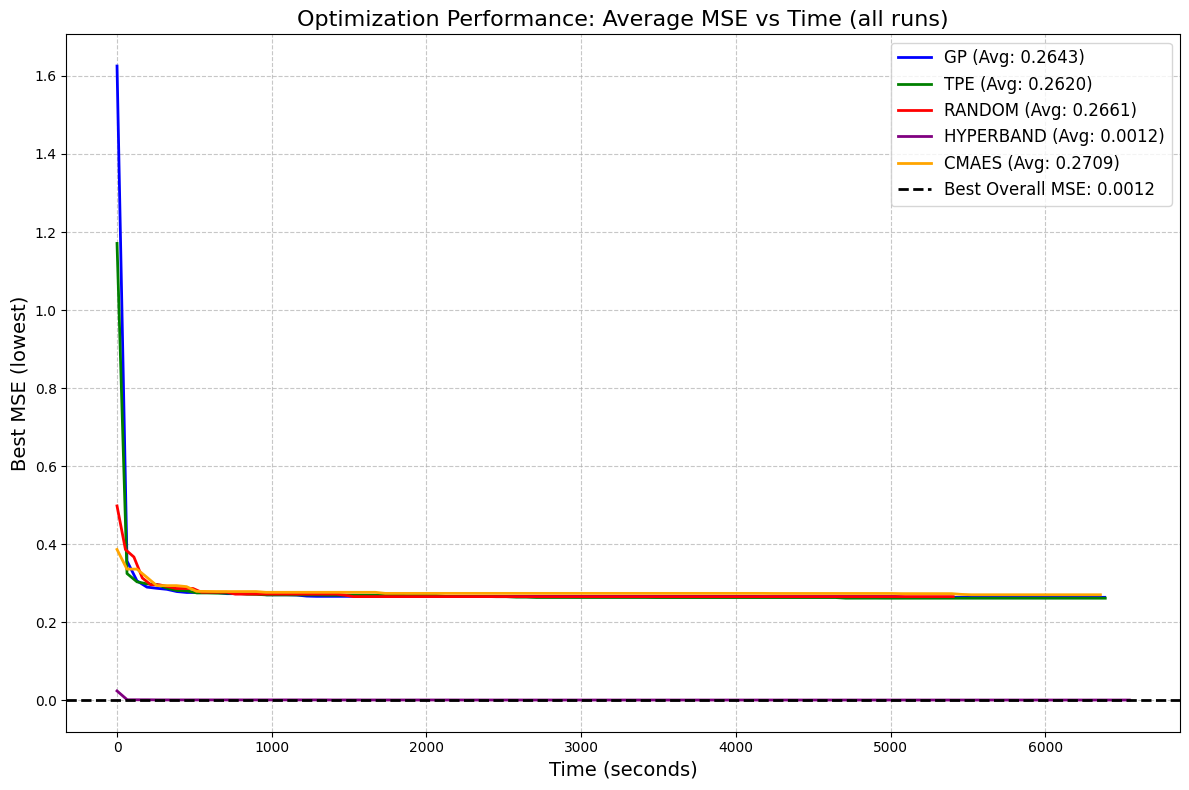

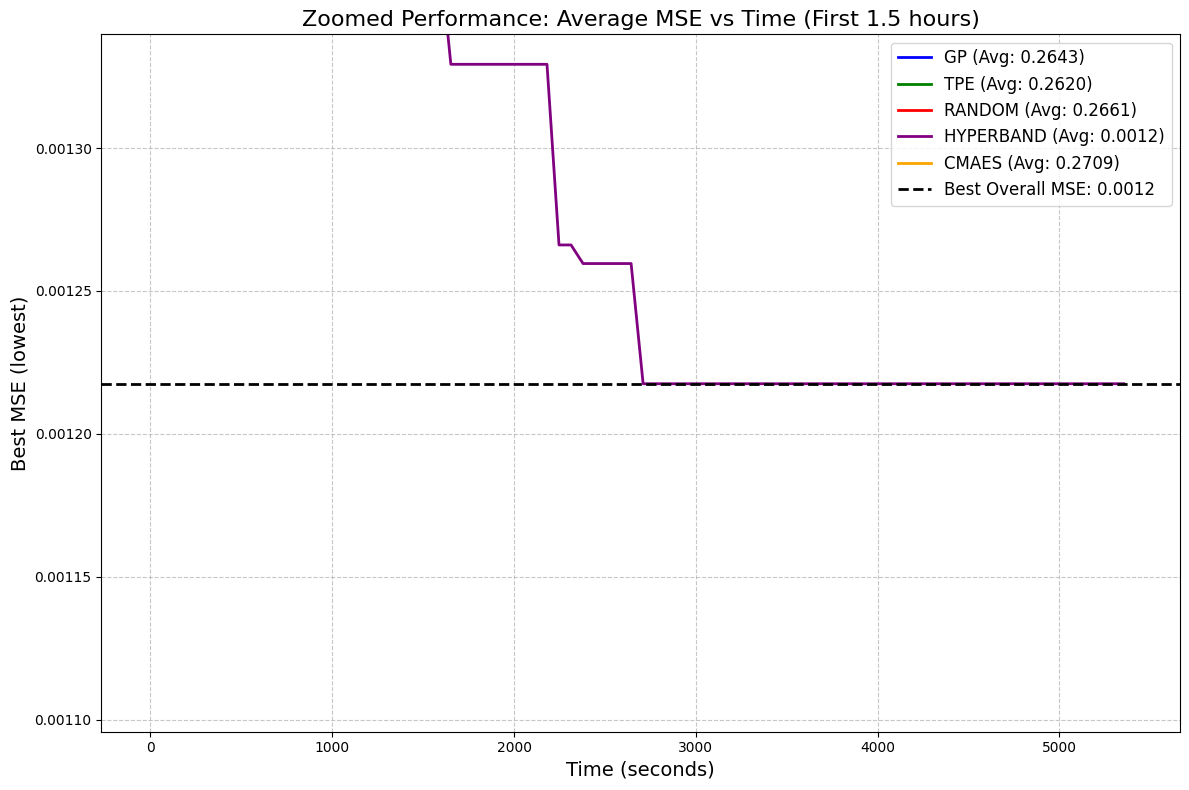

In [10]:
# Load and compare results from all optimization methods
import json
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import defaultdict
from scipy.interpolate import interp1d

# Define the methods to compare
methods = ["GP", "TPE", "RANDOM", "HYPERBAND", "CMAES"]
colors = {
    "GP": "blue",
    "TPE": "green",
    "RANDOM": "red",
    "HYPERBAND": "purple",
    "CMAES": "orange"
}

# Function to load and combine results from multiple runs
def load_results(method):
    results_list = []
    
    if method == "HYPERBAND":
        # Load from all HYPERBAND folders
        try:
            for r in [2, 3, 4]:  # Different reduction factor values
                for i in range(1, 4):  # Load results_1.json, results_2.json, results_3.json
                    file_path = f"results/{method}/n={r}/results_{i}.json"
                    if os.path.exists(file_path):
                        with open(file_path, "r") as f:
                            results_list.append(json.load(f))
                    else:
                        print(f"Warning: File not found - {file_path}")
        except Exception as e:
            print(f"Error loading {method} results: {e}")
    else:
        # Other methods are stored in method/default/
        try:
            for i in range(1, 4):  # Load results_1.json, results_2.json, results_3.json
                file_path = f"results/{method}/default/results_{i}.json"
                if os.path.exists(file_path):
                    with open(file_path, "r") as f:
                        results_list.append(json.load(f))
                else:
                    print(f"Warning: File not found - {file_path}")
        except Exception as e:
            print(f"Error loading {method} results: {e}")
    
    return results_list

# Load results for each method
all_results = {}
for method in methods:
    results = load_results(method)
    if results:
        all_results[method] = results

# Function to extract time series data from a single run
def extract_time_series(results):
    if len(results) <= 1:  # Not enough data
        return None, None
    
    # First entry contains start_time
    if isinstance(results[0], dict) and "start_time" in results[0]:
        start_time = results[0]["start_time"]
        result_entries = results[1:]  # Skip the first entry with start_time
    else:
        # If first entry doesn't have start_time, use the first trial_end as reference
        start_time = min([r.get("trial_end", 0) for r in results if "trial_end" in r])
        result_entries = results
    
    times = []
    mses = []
    best_mse_so_far = float('inf')
    
    for entry in result_entries:
        if "mse" in entry and "trial_end" in entry:
            rel_time = entry["trial_end"] - start_time
            mse = entry["mse"]
            best_mse_so_far = min(best_mse_so_far, mse)
            
            times.append(rel_time)
            mses.append(best_mse_so_far)
    
    # Sort by time to ensure proper plotting
    sorted_data = sorted(zip(times, mses))
    if sorted_data:
        times, mses = zip(*sorted_data)
        return times, mses
    
    return None, None

# Process results for each method and average across runs
plot_data = {}
for method, results_list in all_results.items():
    # Find the best MSE across all runs
    best_mses = []
    time_series_data = []
    
    for results in results_list:
        times, mses = extract_time_series(results)
        if times and mses:
            time_series_data.append((times, mses))
            best_mses.append(min(mses))
    
    if time_series_data:
        # Use the first run's time points as reference for interpolation
        ref_times = np.linspace(0, max([max(times) for times, _ in time_series_data]), 100)
        
        # Interpolate each run's data to the reference time points
        interp_mses = []
        
        for times, mses in time_series_data:
            if len(times) > 1:  # Need at least 2 points for interpolation
                mse_interp = interp1d(times, mses, bounds_error=False, fill_value=(mses[0], mses[-1]))
                interp_mses.append(mse_interp(ref_times))
        
        # Average the interpolated curves
        if interp_mses:
            avg_mses = np.mean(interp_mses, axis=0)
            
            plot_data[method] = {
                "times": ref_times,
                "mses": avg_mses,
                "best_mse": np.mean(best_mses)
            }

# Find the best overall MSE across all methods
best_overall_mse = min([data["best_mse"] for data in plot_data.values()])

# Create the MSE plot
plt.figure(figsize=(12, 8))

for method, data in plot_data.items():
    if "times" in data and "mses" in data:
        plt.plot(data["times"], data["mses"], label=f"{method} (Avg: {data['best_mse']:.4f})", 
                 color=colors[method], linewidth=2)

# Add horizontal line for best MSE
plt.axhline(y=best_overall_mse, color='black', linestyle='--', linewidth=2, 
            label=f'Best Overall MSE: {best_overall_mse:.4f}')

plt.xlabel("Time (seconds)", fontsize=14)
plt.ylabel("Best MSE (lowest)", fontsize=14)
plt.title("Optimization Performance: Average MSE vs Time (all runs)", fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Print final best MSEs (averaged across runs)
print("\nFinal Best MSEs (averaged across all runs):")
for method in sorted(plot_data.keys(), key=lambda x: plot_data[x]["best_mse"]):
    print(f"{method}: {plot_data[method]['best_mse']:.4f}")

plt.show()

# Zoomed in MSE plot (focusing on first 1.5 hours)
plt.figure(figsize=(12, 8))
MAX_TIME = 90 * 60  # 90 minutes = 1.5 hours

for method, data in plot_data.items():
    if "times" in data and "mses" in data:
        # Filter for times less than 1.5 hours
        mask = data["times"] <= MAX_TIME
        if any(mask):
            times = data["times"][mask]
            mses = data["mses"][mask]
            plt.plot(times, mses, label=f"{method} (Avg: {data['best_mse']:.4f})", 
                    color=colors[method], linewidth=2)

# Add horizontal line for best MSE in zoomed plot
plt.axhline(y=best_overall_mse, color='black', linestyle='--', linewidth=2, 
            label=f'Best Overall MSE: {best_overall_mse:.4f}')

plt.xlabel("Time (seconds)", fontsize=14)
plt.ylabel("Best MSE (lowest)", fontsize=14)
plt.title("Zoomed Performance: Average MSE vs Time (First 1.5 hours)", fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
# Set y-axis limit to focus on low MSE values - adjust as needed based on your data
y_min = max(0.0, best_overall_mse * 0.9)
y_max = min([np.percentile(data["mses"], 75) for data in plot_data.values() if len(data["mses"]) > 0])
plt.ylim(y_min, y_max)
plt.tight_layout()
plt.show()
